# Contexto sobre el dataset

El conjunto de datos recoge información diaria sobre la calidad del aire en varias ciudades de la India. Mide la cantidad de diferentes contaminantes en el aire, como partículas pequeñas (PM2.5 y PM10), gases tóxicos (como NO2, CO y SO2) y otros compuestos. Toda esta información se resume en un número llamado Índice de Calidad del Aire (AQI), que nos ayuda a entender qué tan contaminado está el aire y qué riesgos puede tener para la salud en cada ciudad y día.

# Configuraciones iniciales

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Ignorar advertencias para mantener el notebook limpio
warnings.filterwarnings('ignore')

# ----------------------------------------------------
# Configuraciones iniciales
# ----------------------------------------------------
# Establecer semilla global solicitada
SEMILLA_GLOBAL = 30326271
np.random.seed(SEMILLA_GLOBAL)

# Configuraciones visuales de seaborn y matplotlib
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

# Carga de datos

In [13]:
# Carga de datos
df = pd.read_csv('data/city_day.csv')
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


# Descripcion del dataset

In [14]:
print("=== DESCRIPCIÓN DEL DATASET ===")
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}\n")

print("Tipos de datos por columna:")
print(df.dtypes)

=== DESCRIPCIÓN DEL DATASET ===
Número de filas: 29531
Número de columnas: 16

Tipos de datos por columna:
City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket     object
dtype: object


El conjunto de datos tiene 29,531 filas y 16 columnas. La mayoría de las columnas (13) contienen números con decimales, que representan niveles de diferentes químicos en el aire. Solo 3 columnas son de texto o categorías, como la ciudad, la fecha y una clasificación cualitativa del índice de calidad del aire (AQI). Esta forma de organizar los datos es buena para hacer análisis estadísticos y modelos de predicción, pero si queremos estudiar los datos según las fechas, será necesario usar técnicas especiales para manejar series de tiempo.

# Estadistica descriptiva

In [15]:
print("=== ESTADÍSTICAS DESCRIPTIVAS ===")

# Filtrar solo las variables numéricas
variables_numericas = df.select_dtypes(include=[np.number])

# Trasponer (.T) y seleccionar solo las métricas solicitadas
stats_df = variables_numericas.describe().T[['mean', '50%', 'std', 'min', 'max']]

# Renombrar las columnas para cumplir exactamente con lo pedido
stats_df.rename(columns={'mean': 'media', '50%': 'mediana', 'std': 'desv_estandar'}, inplace=True)

# Mostrar la tabla
stats_df

=== ESTADÍSTICAS DESCRIPTIVAS ===


,media,mediana,desv_estandar,min,max
PM2.5,67.450578,48.57,64.661449,0.04,949.99
PM10,118.127103,95.68,90.605110,0.01,1000.00
NO,17.574730,9.89,22.785846,0.02,390.68
NO2,28.560659,21.69,24.474746,0.01,362.21
NOx,32.309123,23.52,31.646011,0.00,467.63
NH3,23.483476,15.85,25.684275,0.01,352.89
CO,2.248598,0.89,6.962884,0.00,175.81
SO2,14.531977,9.16,18.133775,0.01,193.86
O3,34.491430,30.84,21.694928,0.01,257.73
Benzene,3.280840,1.07,15.811136,0.00,455.03


Al analizar los datos, se nota que las partículas en el aire llamadas PM2.5 y PM10, así como el Índice de Calidad del Aire (AQI), tienen un comportamiento muy particular. Por ejemplo, en el caso de PM2.5, el valor medio es más alto que el valor de la mediana, y hay días en que los niveles llegan a ser extremadamente altos, casi 950. Esto nos dice que los datos no están distribuidos de forma equilibrada, sino que hay muchos valores bajos y algunos pocos valores muy altos que hacen que la distribución esté "desbalanceada" hacia la derecha. Además, la gran variación en los valores muestra que la calidad del aire cambia mucho dependiendo del día o la ciudad.

# Valores faltantes

In [16]:
print("===  VALORES FALTANTES ===")
"""
  Calcula la cantidad y el porcentaje de valores nulos por columna,
"""
nulos = df.isnull().sum()
porcentaje = (df.isnull().sum() / len(df)) * 100
reporte = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': porcentaje})
# retornando un DataFrame ordenado de mayor a menor cantidad de nulos.
tabla_nulos =reporte.sort_values(by='Nulos', ascending=False)

tabla_nulos

===  VALORES FALTANTES ===


,Nulos,Porcentaje (%)
Xylene,18109,61.322001
PM10,11140,37.723071
NH3,10328,34.973418
Toluene,8041,27.229014
Benzene,5623,19.041008
AQI,4681,15.851139
AQI_Bucket,4681,15.851139
PM2.5,4598,15.570079
NOx,4185,14.171549
O3,4022,13.619586


Al revisar los datos, encontramos que hay muchos valores que faltan, lo que es un problema importante para la calidad de la información. Por ejemplo, la variable llamada Xylene tiene más del 61% de datos faltantes, PM10 tiene más del 37% y NH3 casi el 35%. Debido a esto, antes de usar estos datos para crear modelos de predicción con Machine Learning, será necesario hacer un trabajo cuidadoso para completar o eliminar esos datos faltantes. Esto es importante para que los modelos no se equivoquen o tengan resultados sesgados.

# Histogramas

=== HISTOGRAMAS ===


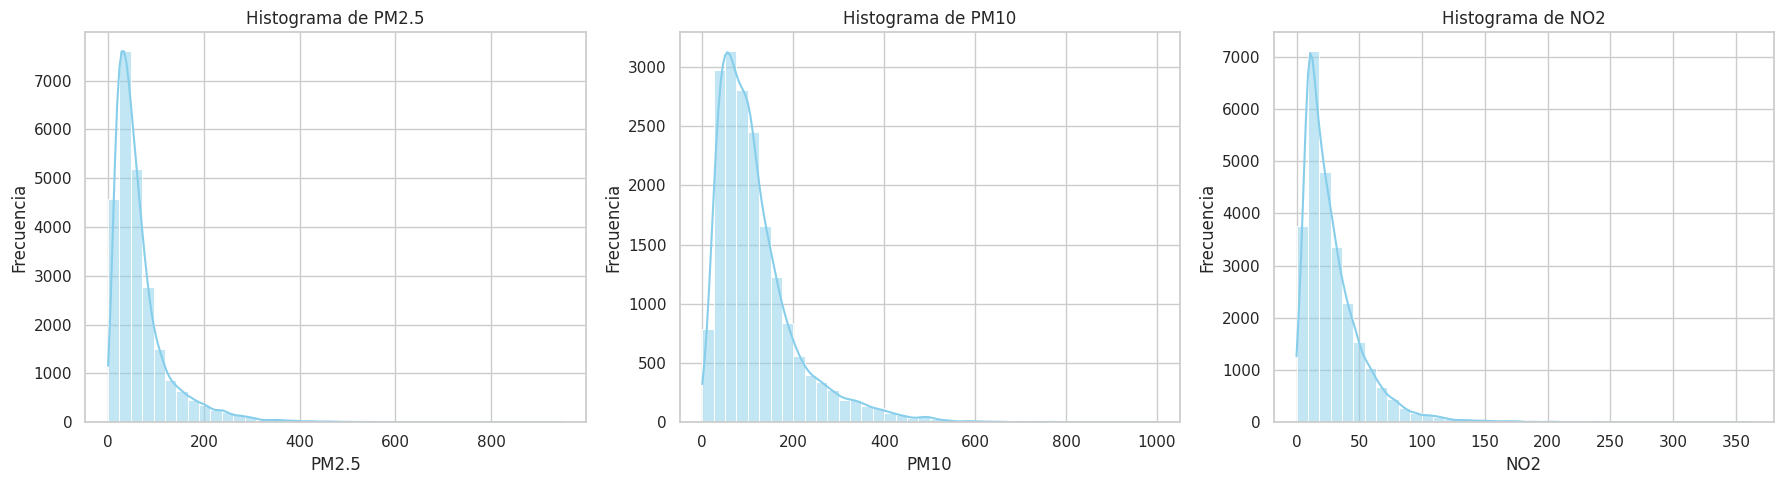

In [17]:
print("=== HISTOGRAMAS ===")
# Seleccionamos 3 variables numéricas representativas de calidad del aire
variables_hist = ['PM2.5', 'PM10', 'NO2']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, var in enumerate(variables_hist):
    sns.histplot(df[var], bins=40, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Histograma de {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Los histogramas muestran claramente lo que ya sospechábamos con los números, las tres variables tienen una distribución muy desigual, con una cola larga hacia la derecha. Esto quiere decir que la mayoría de los días en las ciudades de India los niveles de contaminación están en valores bajos o medios (la mayoría de los datos están en la parte izquierda del gráfico). Pero también hay algunos días en los que la contaminación es muy alta, lo que se refleja en esa cola larga hacia la derecha del histograma.

# Box plots

=== BOX PLOTS E IDENTIFICACIÓN DE OUTLIERS ===


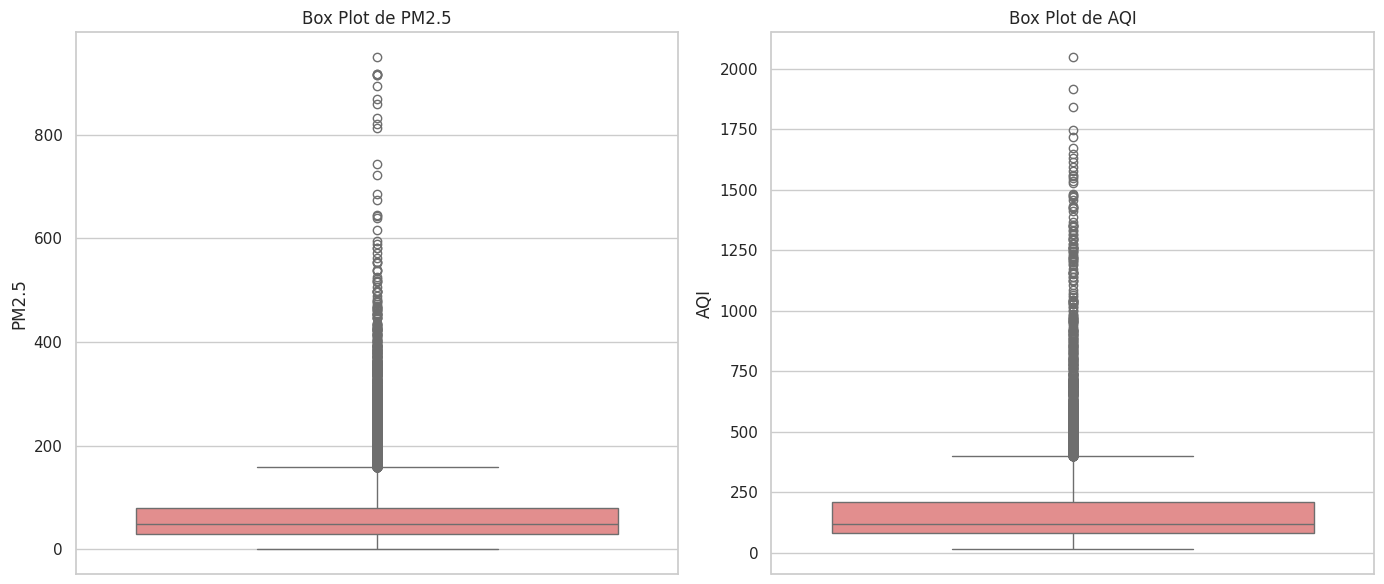

In [18]:
print("=== BOX PLOTS E IDENTIFICACIÓN DE OUTLIERS ===")
# Seleccionamos 2 variables clave
variables_box = ['PM2.5', 'AQI']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, var in enumerate(variables_box):
    sns.boxplot(y=df[var], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Box Plot de {var}')
    axes[i].set_ylabel(var)

plt.tight_layout()
plt.show()

Aqui podemos observar que hay muchos valores fuera de lo común, llamados valores atípicos. La parte central del gráfico, que representa la mitad de los datos, está muy concentrada en la parte baja, mientras que muchos puntos se extienden mucho hacia arriba, más allá del límite normal. Por ejemplo, en el Índice de Calidad del Aire (AQI), hay días en que los valores superan los 2,000, lo que indica condiciones del aire muy malas y poco comunes. Será muy importante decidir si estos valores extremos son errores de los sensores o eventos reales, como incendios o tormentas de arena, para saber cómo manejarlos antes de usar los datos en análisis o modelos.

# Análisis de correlación

## Matriz de correlación

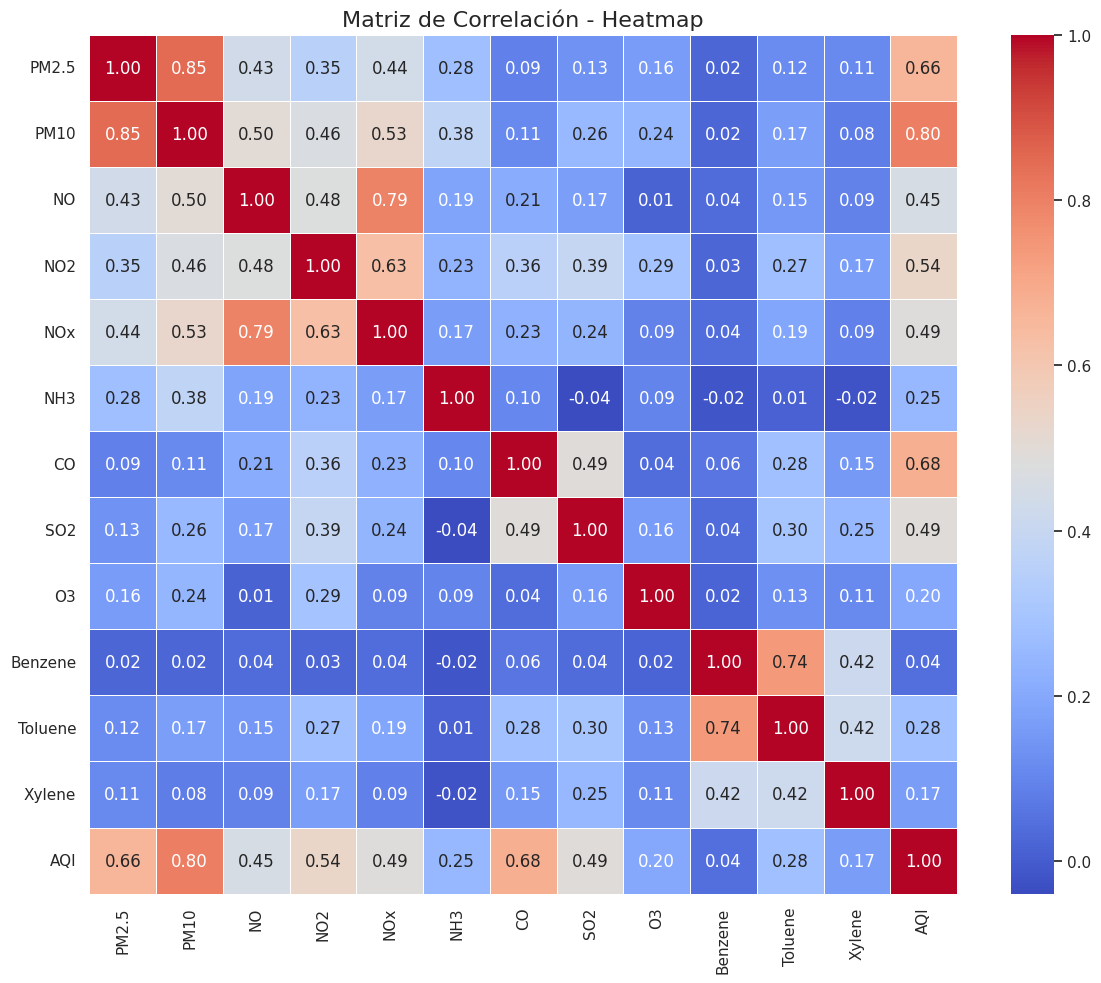

In [19]:
# Calculamos la matriz de correlación solo con variables numéricas
matriz_corr = variables_numericas.corr()

# Generamos el Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación - Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

Esta matriz nos muestra qué tan fuerte es la relación entre las diferentes sustancias químicas. Lo más destacado es que las partículas PM2.5 y PM10 están muy relacionadas, con una correlación alta de alrededor de 0.85. Esto tiene sentido porque ambas son partículas en el aire que vienen de las mismas fuentes, como el tráfico, el polvo o las fábricas.

## Scatter plot

=== ANÁLISIS DE CORRELACIÓN: SCATTER PLOT ===
El par de variables con mayor correlación es 'PM2.5' y 'PM10'
Coeficiente de correlación: 0.8465



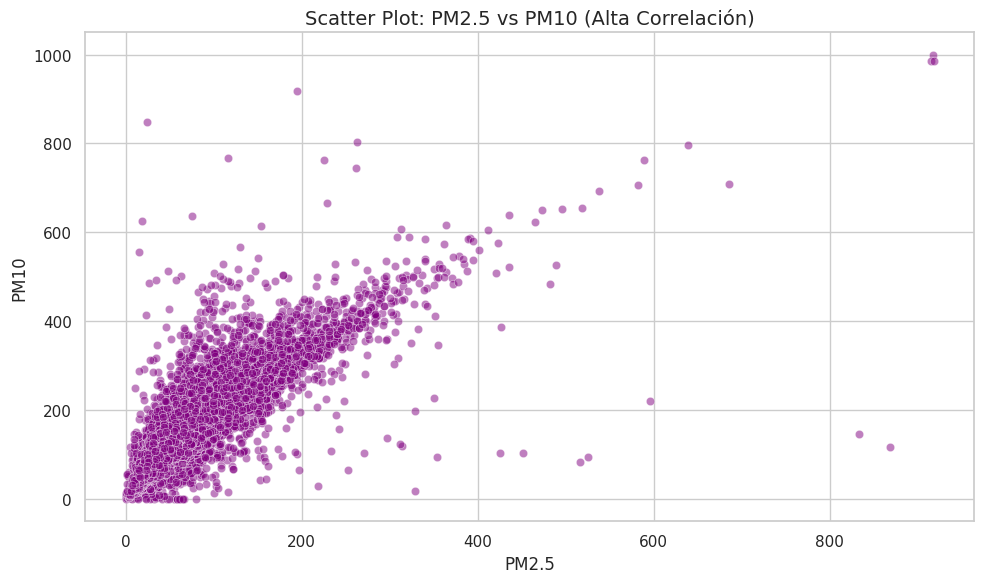

In [20]:
print("=== ANÁLISIS DE CORRELACIÓN: SCATTER PLOT ===")

# Encontrar programáticamente el par de variables con mayor correlación
# Excluimos la diagonal (que siempre es 1.0)
corr_unstacked = matriz_corr.abs().unstack()
corr_unstacked = corr_unstacked[corr_unstacked < 1.0]
var1, var2 = corr_unstacked.idxmax()
correlacion_max = matriz_corr.loc[var1, var2]

print(f"El par de variables con mayor correlación es '{var1}' y '{var2}'")
print(f"Coeficiente de correlación: {correlacion_max:.4f}\n")

# Generamos el Scatter plot para ese par específico
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df[var1], y=df[var2], alpha=0.5, color='purple')
plt.title(f'Scatter Plot: {var1} vs {var2} (Alta Correlación)', fontsize=14)
plt.xlabel(var1)
plt.ylabel(var2)
plt.tight_layout()
plt.show()

En el gráfico de dispersión de estas dos variables, se ve claramente que a medida que una aumenta, la otra también lo hace, formando una línea diagonal hacia arriba. Si en el futuro queremos simplificar los datos o hacer predicciones con modelos como la regresión lineal, podríamos pensar en eliminar una de las dos variables para evitar que estén demasiado relacionadas entre sí, lo que podría causar problemas en el análisis.